# ClauseRisk — Analyses pour la révision (Round 1)

Exécuter les cellules dans l'ordre (**Exécution > Tout exécuter**). La cellule suivante demande d'uploader :
1. `EVAL_external_ENRICHED_MASSIVE.xlsx`
2. `clauserisk_v3_results.xlsx` (avec les votes)
3. *(optionnel)* les fichiers de prédictions v1 / v2

In [1]:
!pip install -q openpyxl scipy scikit-learn
from google.colab import files
uploaded = files.upload()
print(list(uploaded))

Saving clauserisk_v3_results.xlsx to clauserisk_v3_results.xlsx
Saving EVAL_external_ENRICHED_MASSIVE.xlsx to EVAL_external_ENRICHED_MASSIVE.xlsx
['clauserisk_v3_results.xlsx', 'EVAL_external_ENRICHED_MASSIVE.xlsx']


In [2]:
# -*- coding: utf-8 -*-
"""
ClauseRisk — Analyses pour la révision (Applied Sciences, Round 1)
===================================================================
Répond aux commentaires suivants, SANS nouvel appel API
(tout est recalculé à partir des votes déjà sauvegardés) :

  R1.1 / R2.2 / R3.1 / R4.1  -> validation croisée imbriquée (nested CV) + leave-one-language-out
  R1.2 / R3.3 / R4.8         -> tableaux unifiés 3 classes ET binaire, mapping explicite des labels
  R1.3 / R2.1 / R3.2 / R4.2  -> IC bootstrap 95 % (global + par langue) + tests de McNemar
  R1.5 / R2.7 / R4.4         -> courbe risk-coverage, AURC / E-AURC, ECE, Brier, diagramme de fiabilité,
                                comparaison à couverture égale
  R2.6                       -> matrices de confusion binaires, métriques par classe, FN/FP sur HIGH

Utilisation (Google Colab) :
  1. Uploader : EVAL_external_ENRICHED_MASSIVE.xlsx  +  clauserisk_v3_results.xlsx
     (+ optionnel : fichiers de prédictions v1 / v2, voir OPTIONAL_PRED_FILES)
  2. Exécuter :  !python clauserisk_revision_analysis.py
  3. Récupérer : revision_results.xlsx + figures PNG dans revision_outputs/
"""

import os, re, ast, json, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score,
                             cohen_kappa_score, confusion_matrix, f1_score)
from sklearn.model_selection import RepeatedStratifiedKFold

warnings.filterwarnings("ignore")

## 0. CONFIGURATION

In [3]:
# ----------------------------------------------------------------------------
# 0. CONFIGURATION
# ----------------------------------------------------------------------------
EVAL_FILE  = "EVAL_external_ENRICHED_MASSIVE.xlsx"
VOTES_FILE = "clauserisk_v3_results.xlsx"
# Prédictions 3 classes des autres versions (fichier xlsx avec passage_id + colonne de prédiction).
# Laisser None si indisponible.
OPTIONAL_PRED_FILES = {"v1": None, "v2": None}
OUT_DIR  = "revision_outputs"
SEED     = 42
N_BOOT   = 2000     # rééchantillonnages bootstrap
N_SPLITS = 5        # nested CV : plis externes
N_REPEAT = 20       # nested CV : répétitions
TAUS     = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Mapping des labels (R4.8). Vérifié dans le notebook v5 : RISKY = HIGH uniquement.
BINARY_MAP = {"none": 0, "low": 0, "medium": 0, "high": 1}
CLASSES3   = ["low", "medium", "high"]

os.makedirs(OUT_DIR, exist_ok=True)
rng_global = np.random.default_rng(SEED)

## 1. CHARGEMENT

In [4]:
# ----------------------------------------------------------------------------
# 1. CHARGEMENT
# ----------------------------------------------------------------------------
def parse_votes(s):
    if pd.isna(s) or not str(s).strip():
        return []
    try:
        r = ast.literal_eval(str(s).strip())
        if isinstance(r, list):
            return [str(v).lower().strip() for v in r]
    except Exception:
        pass
    return re.findall(r"(none|low|medium|high)", str(s).lower())

df = pd.read_excel(EVAL_FILE, sheet_name="passages")
df = df[df["passage_text"].notna() & df["expected_risk_level"].notna()].copy()
df["gold"] = df["expected_risk_level"].astype(str).str.lower().str.strip()
df = df[df["gold"].isin(BINARY_MAP)].reset_index(drop=True)

votes_sheet = None
for s in pd.ExcelFile(VOTES_FILE).sheet_names:
    tmp = pd.read_excel(VOTES_FILE, sheet_name=s)
    if "votes" in tmp.columns and tmp["votes"].dropna().astype(str).str.strip().ne("").any():
        votes_sheet = s
        break
dv = pd.read_excel(VOTES_FILE, sheet_name=votes_sheet)
dv["votes_parsed"] = dv["votes"].apply(parse_votes)
pred_col = next((c for c in ["pred_v3_FIXED", "pred_v3", "pred"] if c in dv.columns), None)
dv["pred_v3_raw"] = dv[pred_col].astype(str).str.lower().str.strip() if pred_col else ""

if "passage_id" in dv.columns:
    df = df.merge(dv[["passage_id", "votes_parsed", "pred_v3_raw"]], on="passage_id", how="left")
else:
    n = min(len(df), len(dv))
    df = df.iloc[:n].copy()
    df["votes_parsed"] = dv["votes_parsed"].iloc[:n].values
    df["pred_v3_raw"] = dv["pred_v3_raw"].iloc[:n].values
df["votes_parsed"] = df["votes_parsed"].apply(lambda x: x if isinstance(x, list) else [])

N = len(df)
y3 = df["gold"].values
yb = np.array([BINARY_MAP[g] for g in y3])
lang = df["language"].astype(str).str.lower().values
K = np.array([max(len(v), 1) for v in df["votes_parsed"]])
n_high = np.array([sum(1 for x in v if x == "high") for v in df["votes_parsed"]])
p_high = n_high / K                                  # score "RISKY" dans [0,1]
v3_bin = np.array([1 if x == "high" else 0 for x in df["pred_v3_raw"]])

print(f"Passages : {N} | votes par passage : {sorted(set(K))} | sheet votes : {votes_sheet}")
print("Gold 3 classes :", dict(pd.Series(y3).value_counts()))
print("Gold binaire   : RISKY =", yb.sum(), "| NOT-RISKY =", N - yb.sum())

Passages : 81 | votes par passage : [np.int64(5)] | sheet votes : v3_predictions
Gold 3 classes : {'high': np.int64(37), 'medium': np.int64(26), 'low': np.int64(18)}
Gold binaire   : RISKY = 37 | NOT-RISKY = 44


## 2. KEYWORD VETO (copie exacte du notebook v5)

In [5]:
# ----------------------------------------------------------------------------
# 2. KEYWORD VETO (copie exacte du notebook v5)
# ----------------------------------------------------------------------------
HIGH_KEYWORDS = {
    "fr": [r"\brenonc(?:e|ez|er|iation)\s+(?:irr[ée]vocablement|à\s+tout\s+droit)",
           r"exclusivement\s+devant\s+(?:un|le|les)\s+tribunal",
           r"d[ée]gag[eé]?\s+toute\s+(?:sa\s+)?responsabilit[ée]",
           r"transf[ée]r[ée]s?\s+(?:vers|en|hors)\s+(?:la\s+)?(?:R[ée]publique\s+populaire\s+de\s+)?Chine",
           r"lois?\s+(?:de\s+l['\u2019])?(?:[ée]tat\s+de\s+)?Californie",
           r"r[ée]gis?\s+par\s+les\s+lois\s+de\s+Singapour",
           r"reconnaissance\s+faciale", r"donn[ée]es\s+biom[ée]triques",
           r"cession\s+(?:à\s+titre\s+)?on[ée]reuse?"],
    "en": [r"\birrevocably\s+waive", r"exclusively\s+before\s+(?:a|the)\s+court",
           r"governed\s+by\s+the\s+laws\s+of\s+(?:Singapore|California|the\s+Northern\s+District)",
           r"transferred\s+to\s+(?:and\s+)?(?:stored|processed)\s+(?:in|at).*China",
           r"People['\u2019]?s\s+Republic\s+of\s+China", r"facial\s+recognition",
           r"biometric\s+(?:data|information)", r"binding\s+arbitration",
           r"(?:perpetual|irrevocable)\s+(?:.*)?(?:licens|royalty-free)",
           r"sublicensable\s+and\s+transferable"],
    "ar": [r"تتنازل\s+عن", r"محاكم\s+ولاية\s+كاليفورنيا", r"قوانين\s+سنغافورة",
           r"جمهورية\s+الصين", r"بيانات\s+بيومترية", r"التعرف\s+على\s+الوجه"],
}

def keyword_veto(text, lg):
    pats = HIGH_KEYWORDS.get(str(lg).lower(), []) + HIGH_KEYWORDS["en"]
    return any(re.search(p, str(text).lower(), re.IGNORECASE) for p in pats)

kw = np.array([keyword_veto(t, l) for t, l in zip(df["passage_text"], lang)])
print(f"Keyword veto : {kw.sum()} passages, dont {yb[kw].sum()} vraiment HIGH")

Keyword veto : 15 passages, dont 14 vraiment HIGH


## 3. RÈGLES DE DÉCISION ET SCORES DE CONFIANCE

In [6]:
# ----------------------------------------------------------------------------
# 3. RÈGLES DE DÉCISION ET SCORES DE CONFIANCE
# ----------------------------------------------------------------------------
CONFIGS = [dict(k=k, kw=u_kw, v3=u_v3)
           for k in [1, 2, 3] for u_kw in [False, True] for u_v3 in [False, True]]

def cfg_name(c):
    return f">={c['k']} votes" + (" +KW" if c["kw"] else "") + (" +v3" if c["v3"] else "")

def decide(c, idx=None):
    idx = np.arange(N) if idx is None else idx
    pred = (n_high[idx] >= c["k"]).astype(int)
    if c["kw"]: pred = np.maximum(pred, kw[idx].astype(int))
    if c["v3"]: pred = np.maximum(pred, v3_bin[idx])
    return pred

def conf_original(idx=None):
    """Score tel qu'implémenté dans le notebook v5 (confiance d'être HIGH, pas du label prédit)."""
    idx = np.arange(N) if idx is None else idx
    return np.minimum(1.0, p_high[idx] + 0.20 * kw[idx] + 0.15 * v3_bin[idx])

def conf_agreement(pred, idx=None):
    """Équation (2) de l'article : part des votes en accord avec le label prédit."""
    idx = np.arange(N) if idx is None else idx
    return np.where(pred == 1, p_high[idx], 1.0 - p_high[idx])

## 4. MÉTRIQUES + BOOTSTRAP + McNEMAR

In [7]:
# ----------------------------------------------------------------------------
# 4. MÉTRIQUES + BOOTSTRAP + McNEMAR
# ----------------------------------------------------------------------------
def bin_metrics(y, p):
    pr, rc, f1, _ = precision_recall_fscore_support(y, p, average="binary", zero_division=0)
    kap = cohen_kappa_score(y, p) if len(np.unique(np.r_[y, p])) > 1 else np.nan
    return dict(precision=pr, recall=rc, f1=f1, accuracy=accuracy_score(y, p), kappa=kap)

def boot_ci(y, p, idx=None, n_boot=N_BOOT, seed=SEED):
    """IC percentile 95 %, rééchantillonnage stratifié par classe."""
    idx = np.arange(len(y)) if idx is None else np.asarray(idx)
    y, p = y[idx], p[idx]
    rng = np.random.default_rng(seed)
    pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
    draws = {m: [] for m in ["precision", "recall", "f1", "accuracy", "kappa"]}
    for _ in range(n_boot):
        b = np.r_[rng.choice(pos, len(pos)), rng.choice(neg, len(neg))] if len(pos) and len(neg) \
            else rng.choice(len(y), len(y))
        for m, v in bin_metrics(y[b], p[b]).items():
            draws[m].append(v)
    point = bin_metrics(y, p)
    return {m: (point[m], np.nanpercentile(draws[m], 2.5), np.nanpercentile(draws[m], 97.5))
            for m in draws}

def fmt(t):
    return f"{t[0]:.3f} [{t[1]:.3f}–{t[2]:.3f}]"

def mcnemar(y, pa, pb):
    a_ok, b_ok = pa == y, pb == y
    b = int(np.sum(a_ok & ~b_ok)); c = int(np.sum(~a_ok & b_ok))
    p = binomtest(b, b + c, 0.5).pvalue if b + c > 0 else 1.0
    return b, c, p

## 5. GRILLE COMPLÈTE (reproduit Section 6.6.3) + IC

In [8]:
# ----------------------------------------------------------------------------
# 5. GRILLE COMPLÈTE (reproduit Section 6.6.3) + IC
# ----------------------------------------------------------------------------
grid_rows = []
for c in CONFIGS:
    ci = boot_ci(yb, decide(c))
    grid_rows.append({"config": cfg_name(c), **{m: fmt(ci[m]) for m in ci},
                      "f1_point": ci["f1"][0]})
df_grid = pd.DataFrame(grid_rows).sort_values("f1_point", ascending=False)
print("\n=== Grille 12 configurations (évaluée sur tout EVAL-EEM = résultats de DÉVELOPPEMENT) ===")
print(df_grid.drop(columns="f1_point").to_string(index=False))

# Versions dérivées des mêmes votes
V4 = dict(k=3, kw=False, v3=False)
V5 = max(CONFIGS, key=lambda c: f1_score(yb, decide(c), zero_division=0))
print(f"\nConfig sélectionnée (in-sample) : {cfg_name(V5)}")


=== Grille 12 configurations (évaluée sur tout EVAL-EEM = résultats de DÉVELOPPEMENT) ===
           config           precision              recall                  f1            accuracy               kappa
    >=1 votes +KW 0.829 [0.725–0.938] 0.784 [0.649–0.919] 0.806 [0.696–0.892] 0.827 [0.741–0.901] 0.650 [0.472–0.801]
        >=1 votes 0.848 [0.743–0.964] 0.757 [0.595–0.892] 0.800 [0.686–0.889] 0.827 [0.741–0.901] 0.649 [0.467–0.800]
    >=2 votes +KW 0.824 [0.714–0.938] 0.757 [0.622–0.892] 0.789 [0.677–0.882] 0.815 [0.728–0.889] 0.624 [0.443–0.778]
        >=2 votes 0.844 [0.733–0.963] 0.730 [0.568–0.865] 0.783 [0.667–0.880] 0.815 [0.728–0.889] 0.623 [0.443–0.777]
    >=3 votes +KW 0.833 [0.719–0.962] 0.676 [0.541–0.811] 0.746 [0.625–0.848] 0.790 [0.704–0.877] 0.571 [0.392–0.747]
        >=3 votes 0.857 [0.741–0.964] 0.649 [0.486–0.811] 0.738 [0.607–0.845] 0.790 [0.704–0.864] 0.569 [0.390–0.725]
>=1 votes +KW +v3 0.521 [0.487–0.569] 1.000 [1.000–1.000] 0.685 [0.655–0.725] 0.580

## 6. NESTED CV (sélection de config ET de tau à l'intérieur des plis)

In [9]:
# ----------------------------------------------------------------------------
# 6. NESTED CV (sélection de config ET de tau à l'intérieur des plis)
# ----------------------------------------------------------------------------
strat = np.array([f"{l}_{g}" for l, g in zip(lang, yb)])
# fusionne les strates trop petites pour StratifiedKFold
counts = pd.Series(strat).value_counts()
strat = np.array([s if counts[s] >= N_SPLITS else f"x_{s.split('_')[1]}" for s in strat])

def select_config(tr):
    scores = [(f1_score(yb[tr], decide(c, tr), zero_division=0), -i) for i, c in enumerate(CONFIGS)]
    return CONFIGS[-max(scores)[1]]

def select_tau(c, tr, min_cov=0.5):
    """tau le plus élevé qui garde >= min_cov de couverture sur le pli d'entraînement."""
    conf = conf_agreement(decide(c, tr), tr)
    ok = [t for t in TAUS if (conf >= t).mean() >= min_cov]
    return max(ok) if ok else min(TAUS)

rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEAT, random_state=SEED)
oof = np.full((N_REPEAT, N), -1)
sel_mask = np.zeros((N_REPEAT, N), bool)
chosen = []
for i, (tr, te) in enumerate(rskf.split(np.zeros(N), strat)):
    r = i // N_SPLITS
    c = select_config(tr)
    chosen.append(cfg_name(c))
    oof[r, te] = decide(c, te)
    tau = select_tau(c, tr)
    sel_mask[r, te] = conf_agreement(oof[r, te], te) >= tau

rep_f1  = [f1_score(yb, oof[r], zero_division=0) for r in range(N_REPEAT)]
rep_acc = [accuracy_score(yb, oof[r]) for r in range(N_REPEAT)]
rep_sel = []
for r in range(N_REPEAT):
    m = sel_mask[r]
    rep_sel.append((m.mean(), accuracy_score(yb[m], oof[r][m]) if m.any() else np.nan,
                    f1_score(yb[m], oof[r][m], zero_division=0) if m.any() else np.nan))
rep_sel = np.array(rep_sel)
nested = pd.DataFrame([
    {"metric": "F1 binaire (nested CV)", "mean": np.mean(rep_f1), "sd": np.std(rep_f1),
     "min": np.min(rep_f1), "max": np.max(rep_f1)},
    {"metric": "Accuracy (nested CV)", "mean": np.mean(rep_acc), "sd": np.std(rep_acc),
     "min": np.min(rep_acc), "max": np.max(rep_acc)},
    {"metric": "Selective coverage", "mean": np.nanmean(rep_sel[:, 0]), "sd": np.nanstd(rep_sel[:, 0]),
     "min": np.nanmin(rep_sel[:, 0]), "max": np.nanmax(rep_sel[:, 0])},
    {"metric": "Selective accuracy", "mean": np.nanmean(rep_sel[:, 1]), "sd": np.nanstd(rep_sel[:, 1]),
     "min": np.nanmin(rep_sel[:, 1]), "max": np.nanmax(rep_sel[:, 1])},
    {"metric": "Selective F1", "mean": np.nanmean(rep_sel[:, 2]), "sd": np.nanstd(rep_sel[:, 2]),
     "min": np.nanmin(rep_sel[:, 2]), "max": np.nanmax(rep_sel[:, 2])},
]).round(3)
freq = pd.Series(chosen).value_counts().rename_axis("config").reset_index(name="times_selected")
print(f"\n=== Nested CV ({N_REPEAT}x{N_SPLITS}-fold) ===")
print(nested.to_string(index=False))
print(freq.to_string(index=False))

# Leave-one-language-out : sélection sur 2 langues, test sur la 3e
lolo = []
for L in sorted(set(lang)):
    tr, te = np.where(lang != L)[0], np.where(lang == L)[0]
    c = select_config(tr)
    ci = boot_ci(yb, decide(c), idx=te)
    lolo.append({"test_language": L, "n": len(te), "config_selected": cfg_name(c),
                 **{m: fmt(ci[m]) for m in ["f1", "accuracy", "precision", "recall"]}})
df_lolo = pd.DataFrame(lolo)
print("\n=== Leave-one-language-out ===")
print(df_lolo.to_string(index=False))


=== Nested CV (20x5-fold) ===
                metric  mean    sd   min   max
F1 binaire (nested CV) 0.792 0.005 0.789 0.800
  Accuracy (nested CV) 0.818 0.005 0.815 0.827
    Selective coverage 0.880 0.005 0.877 0.889
    Selective accuracy 0.860 0.001 0.859 0.861
          Selective F1 0.821 0.000 0.821 0.821
       config  times_selected
>=1 votes +KW              80
    >=1 votes              20

=== Leave-one-language-out ===
test_language  n config_selected                  f1            accuracy           precision              recall
           ar 19   >=1 votes +KW 0.875 [0.615–1.000] 0.895 [0.737–1.000] 1.000 [1.000–1.000] 0.778 [0.444–1.000]
           en 26   >=1 votes +KW 0.786 [0.615–0.929] 0.769 [0.615–0.923] 0.786 [0.625–1.000] 0.786 [0.571–1.000]
           fr 36       >=1 votes 0.741 [0.545–0.897] 0.806 [0.667–0.917] 0.769 [0.579–1.000] 0.714 [0.498–0.929]


## 7. IC GLOBAUX, PAR LANGUE, PAR STRATE + McNEMAR

In [10]:
# ----------------------------------------------------------------------------
# 7. IC GLOBAUX, PAR LANGUE, PAR STRATE + McNEMAR
# ----------------------------------------------------------------------------
systems = {"v4 (>=3 votes)": decide(V4), f"v5 ({cfg_name(V5)})": decide(V5),
           ">=2 votes": decide(dict(k=2, kw=False, v3=False)),
           "v3 bug (binarised)": v3_bin}
ci_rows = []
for name, p in systems.items():
    ci = boot_ci(yb, p)
    ci_rows.append({"system": name, "subset": "all", "n": N, **{m: fmt(ci[m]) for m in ci}})
    for L in sorted(set(lang)):
        idx = np.where(lang == L)[0]
        ci = boot_ci(yb, p, idx=idx)
        ci_rows.append({"system": name, "subset": f"lang={L}", "n": len(idx),
                        **{m: fmt(ci[m]) for m in ci}})
    if "strata" in df.columns:
        for S in df["strata"].dropna().unique():
            idx = np.where(df["strata"].values == S)[0]
            ci_rows.append({"system": name, "subset": f"strata={S}", "n": len(idx),
                            "accuracy": fmt(boot_ci(yb, p, idx=idx)["accuracy"])})
df_ci = pd.DataFrame(ci_rows)

mc_rows = []
names = list(systems)
for a, b in itertools.combinations(names, 2):
    nb_, nc_, pv = mcnemar(yb, systems[a], systems[b])
    mc_rows.append({"A": a, "B": b, "A right/B wrong": nb_, "A wrong/B right": nc_,
                    "p (exact McNemar)": round(pv, 4)})
df_mc = pd.DataFrame(mc_rows)
print("\n=== McNemar ===")
print(df_mc.to_string(index=False))


=== McNemar ===
                 A                  B  A right/B wrong  A wrong/B right  p (exact McNemar)
    v4 (>=3 votes) v5 (>=1 votes +KW)                2                5             0.4531
    v4 (>=3 votes)          >=2 votes                1                3             0.6250
    v4 (>=3 votes) v3 bug (binarised)               30               13             0.0137
v5 (>=1 votes +KW)          >=2 votes                2                1             1.0000
v5 (>=1 votes +KW) v3 bug (binarised)               28                8             0.0012
         >=2 votes v3 bug (binarised)               29               10             0.0034


## 8. ANALYSE D'ERREURS (R2.6)

In [11]:
# ----------------------------------------------------------------------------
# 8. ANALYSE D'ERREURS (R2.6)
# ----------------------------------------------------------------------------
pv5 = decide(V5)
cm = confusion_matrix(yb, pv5, labels=[0, 1])
err = pd.DataFrame({"gold_3class": y3, "pred_v5_binary": pv5})
err_tab = pd.crosstab(err["gold_3class"], err["pred_v5_binary"]).rename(
    columns={0: "pred NOT-RISKY", 1: "pred RISKY"})
pc = precision_recall_fscore_support(yb, pv5, labels=[0, 1], zero_division=0)
df_perclass = pd.DataFrame({"class": ["NOT-RISKY", "RISKY"], "precision": pc[0],
                            "recall": pc[1], "f1": pc[2], "support": pc[3]}).round(3)
fn_list = df.loc[(yb == 1) & (pv5 == 0), ["passage_id", "language", "passage_text"]]
fp_list = df.loc[(yb == 0) & (pv5 == 1), ["passage_id", "language", "gold", "passage_text"]]
print(f"\nv5 : TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")
print(err_tab)

# 3 classes à partir des votes (vote majoritaire, tie -> classe la plus grave)
SEV = {"none": 0, "low": 1, "medium": 2, "high": 3}
def majority3(votes, w_first=1.5):
    if not votes: return "low"
    sc = {}
    for i, v in enumerate(votes):
        sc[v] = sc.get(v, 0) + (w_first if i == 0 else 1.0)
    best = max(sc.values())
    lab = max([v for v in sc if sc[v] == best], key=lambda v: SEV.get(v, 0))
    return "low" if lab == "none" else lab
pred3_votes = np.array([majority3(v) for v in df["votes_parsed"]])


v5 : TN=38 FP=6 FN=8 TP=29
pred_v5_binary  pred NOT-RISKY  pred RISKY
gold_3class                               
high                         8          29
low                         18           0
medium                      20           6


## 9. TABLEAU UNIFIÉ 3 CLASSES / BINAIRE (R1.2, R3.3)

In [12]:
# ----------------------------------------------------------------------------
# 9. TABLEAU UNIFIÉ 3 CLASSES / BINAIRE (R1.2, R3.3)
# ----------------------------------------------------------------------------
def load_optional(path):
    d = pd.read_excel(path)
    col = next(c for c in d.columns if "pred" in c.lower())
    d["p"] = d[col].astype(str).str.lower().str.strip().replace({"none": "low"})
    return df[["passage_id"]].merge(d[["passage_id", "p"]], on="passage_id", how="left")["p"].fillna("low").values

unified_src = {}
for v, path in OPTIONAL_PRED_FILES.items():
    if path and os.path.exists(path):
        unified_src[v] = load_optional(path)
unified_src["v3 (bug, as run)"] = np.array([x if x in CLASSES3 else "low" for x in df["pred_v3_raw"]])
unified_src["v3-FIXED (votes, weighted majority)"] = pred3_votes

uni = []
for v, p3 in unified_src.items():
    pb = np.array([BINARY_MAP.get(x, 0) for x in p3])
    uni.append({"version": v,
                "3-class macro-F1": round(f1_score(y3, p3, labels=CLASSES3, average="macro", zero_division=0), 3),
                "3-class acc": round(accuracy_score(y3, p3), 3),
                "3-class kappa": round(cohen_kappa_score(y3, p3), 3),
                "binary F1": fmt(boot_ci(yb, pb)["f1"])})
for v, pb in [("v4 (>=3 votes)", decide(V4)), (f"v5 ({cfg_name(V5)})", pv5)]:
    uni.append({"version": v, "3-class macro-F1": "n/a (binary rule)", "3-class acc": "n/a",
                "3-class kappa": "n/a", "binary F1": fmt(boot_ci(yb, pb)["f1"])})
df_uni = pd.DataFrame(uni)
print("\n=== Tableau unifié ===")
print(df_uni.to_string(index=False))
print("-> vérifier que 'v3-FIXED (votes)' retrouve 0.680 ; sinon adapter majority3().")


=== Tableau unifié ===
                            version  3-class macro-F1 3-class acc 3-class kappa           binary F1
                   v3 (bug, as run)             0.228       0.457          0.03 0.685 [0.655–0.725]
v3-FIXED (votes, weighted majority)              0.68       0.679         0.516 0.738 [0.607–0.845]
                     v4 (>=3 votes) n/a (binary rule)         n/a           n/a 0.738 [0.607–0.845]
                 v5 (>=1 votes +KW) n/a (binary rule)         n/a           n/a 0.806 [0.696–0.892]
-> vérifier que 'v3-FIXED (votes)' retrouve 0.680 ; sinon adapter majority3().


## 10. SÉLECTIF : RISK-COVERAGE, AURC, CALIBRATION (R1.5, R2.7, R4.4)

In [13]:
# ----------------------------------------------------------------------------
# 10. SÉLECTIF : RISK-COVERAGE, AURC, CALIBRATION (R1.5, R2.7, R4.4)
# ----------------------------------------------------------------------------
def risk_coverage(y, p, conf, seed=SEED):
    rng = np.random.default_rng(seed)
    order = np.lexsort((rng.random(len(conf)), -conf))      # ex-aequo départagés au hasard
    errs = (p[order] != y[order]).astype(float)
    cov = np.arange(1, len(y) + 1) / len(y)
    risk = np.cumsum(errs) / np.arange(1, len(y) + 1)
    return cov, risk

def aurc(y, p, conf, n_rep=200):
    vals = [risk_coverage(y, p, conf, seed=s)[1].mean() for s in range(n_rep)]
    return float(np.mean(vals))

def oracle_aurc(y, p):
    e = (p != y).astype(float)
    return risk_coverage(y, p, -e)[1].mean()   # erreurs en dernier

sel_rows, rc_curves = [], {}
for name, pred in [("v4 (>=3 votes)", decide(V4)), (f"v5 ({cfg_name(V5)})", pv5)]:
    for cname, conf in [("agreement (Eq. 2)", conf_agreement(pred)),
                        ("original notebook score", conf_original())]:
        a = aurc(yb, pred, conf); o = oracle_aurc(yb, pred)
        sel_rows.append({"system": name, "confidence": cname, "AURC": round(a, 4),
                         "E-AURC": round(a - o, 4), "full-coverage risk": round((pred != yb).mean(), 4)})
        rc_curves[(name, cname)] = risk_coverage(yb, pred, conf)
df_aurc = pd.DataFrame(sel_rows)
print("\n=== AURC ===")
print(df_aurc.to_string(index=False))

# Couverture égale : accuracy / F1 sur les x % les plus confiants
eq_rows = []
for cov_target in [0.3, 0.5, 0.7, 0.9, 1.0]:
    m_ = int(round(cov_target * N))
    for name, pred in [("v4 (>=3 votes)", decide(V4)), (f"v5 ({cfg_name(V5)})", pv5)]:
        conf = conf_agreement(pred)
        order = np.lexsort((np.random.default_rng(SEED).random(N), -conf))[:m_]
        eq_rows.append({"coverage": cov_target, "system": name, "n": m_,
                        "selective acc": round(accuracy_score(yb[order], pred[order]), 3),
                        "selective F1": round(f1_score(yb[order], pred[order], zero_division=0), 3),
                        "n gold RISKY retained": int(yb[order].sum()),
                        "n gold NOT-RISKY retained": int((1 - yb[order]).sum())})
df_eq = pd.DataFrame(eq_rows)

# Tableau 15 recalculé avec les deux scores (montre le problème TN = 0)
t15 = []
for cname, conf in [("original notebook score", conf_original()), ("agreement (Eq. 2)", conf_agreement(pv5))]:
    for t in TAUS:
        m = conf >= t
        if m.sum() == 0: continue
        cmx = confusion_matrix(yb[m], pv5[m], labels=[0, 1])
        t15.append({"confidence": cname, "tau": t, "coverage": round(m.mean(), 3), "n": int(m.sum()),
                    "F1": round(f1_score(yb[m], pv5[m], zero_division=0), 3),
                    "acc": round(accuracy_score(yb[m], pv5[m]), 3),
                    "TN": cmx[0, 0], "FP": cmx[0, 1], "FN": cmx[1, 0], "TP": cmx[1, 1]})
df_t15 = pd.DataFrame(t15)
print("\n=== Table 15 recalculée ===")
print(df_t15.to_string(index=False))

# Calibration du score p_high (probabilité RISKY)
def calib(y, prob):
    rows, ece = [], 0.0
    for v in np.unique(prob):
        m = prob == v
        rows.append({"p_high": round(v, 3), "n": int(m.sum()), "observed RISKY rate": round(y[m].mean(), 3)})
        ece += m.mean() * abs(y[m].mean() - v)
    return pd.DataFrame(rows), ece, float(np.mean((prob - y) ** 2))
df_rel, ece, brier = calib(yb, p_high)
df_rel_orig, ece_o, brier_o = calib(yb, conf_original())
df_calib = pd.DataFrame([
    {"score": "p_high = n_high/K", "ECE": round(ece, 4), "Brier": round(brier, 4)},
    {"score": "original notebook score (+0.20/+0.15)", "ECE": round(ece_o, 4), "Brier": round(brier_o, 4)},
    {"score": "reference: constant base rate", "ECE": 0.0, "Brier": round(yb.mean() * (1 - yb.mean()), 4)}])
print("\n=== Calibration ===")
print(df_calib.to_string(index=False))


=== AURC ===
            system              confidence   AURC  E-AURC  full-coverage risk
    v4 (>=3 votes)       agreement (Eq. 2) 0.1387  0.1136              0.2099
    v4 (>=3 votes) original notebook score 0.1710  0.1459              0.2099
v5 (>=1 votes +KW)       agreement (Eq. 2) 0.1294  0.1125              0.1728
v5 (>=1 votes +KW) original notebook score 0.1354  0.1184              0.1728

=== Table 15 recalculée ===
             confidence  tau  coverage  n    F1   acc  TN  FP  FN  TP
original notebook score  0.5     0.395 32 0.915 0.844   0   5   0  27
original notebook score  0.6     0.346 28 0.923 0.857   0   4   0  24
original notebook score  0.7     0.346 28 0.923 0.857   0   4   0  24
original notebook score  0.8     0.309 25 0.980 0.960   0   1   0  24
original notebook score  0.9     0.309 25 0.980 0.960   0   1   0  24
original notebook score  1.0     0.309 25 0.980 0.960   0   1   0  24
      agreement (Eq. 2)  0.5     0.914 74 0.800 0.838  38   4   8  24
      a

## 11. FIGURES

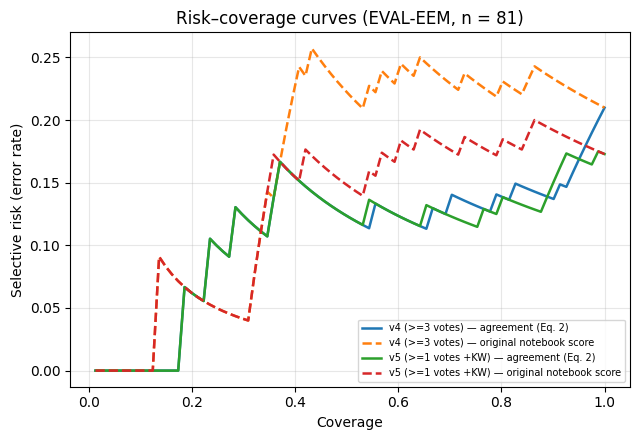

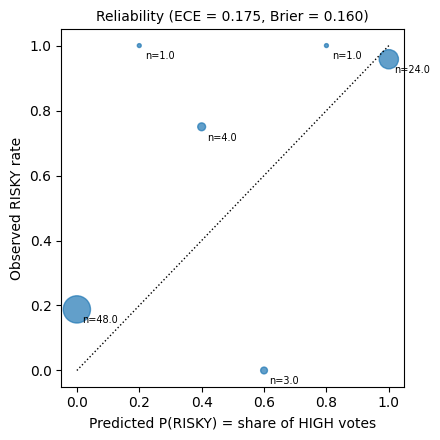

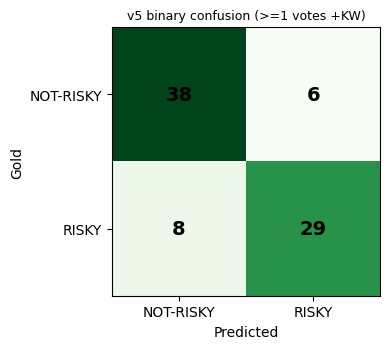

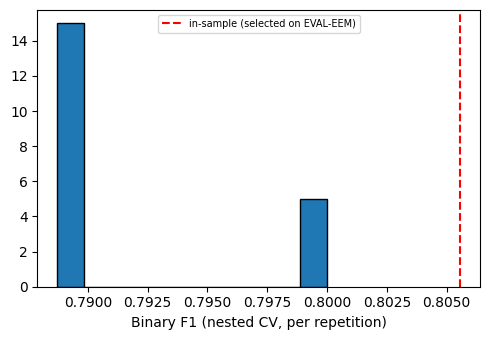

In [14]:
# ----------------------------------------------------------------------------
# 11. FIGURES
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for (name, cname), (cov, risk) in rc_curves.items():
    ax.plot(cov, risk, label=f"{name} — {cname}", lw=1.8,
            ls="-" if "agreement" in cname else "--")
ax.set_xlabel("Coverage"); ax.set_ylabel("Selective risk (error rate)")
ax.set_title("Risk–coverage curves (EVAL-EEM, n = %d)" % N)
ax.legend(fontsize=7); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/risk_coverage.png", dpi=300)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], "k:", lw=1)
ax.scatter(df_rel["p_high"], df_rel["observed RISKY rate"], s=df_rel["n"] * 8, alpha=.7)
for _, r in df_rel.iterrows():
    ax.annotate(f"n={r['n']}", (r["p_high"], r["observed RISKY rate"]), fontsize=7,
                xytext=(4, -10), textcoords="offset points")
ax.set_xlabel("Predicted P(RISKY) = share of HIGH votes"); ax.set_ylabel("Observed RISKY rate")
ax.set_title(f"Reliability (ECE = {ece:.3f}, Brier = {brier:.3f})", fontsize=10)
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/reliability.png", dpi=300)

fig, ax = plt.subplots(figsize=(4, 3.6))
ax.imshow(cm, cmap="Greens")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14, weight="bold")
ax.set_xticks([0, 1]); ax.set_xticklabels(["NOT-RISKY", "RISKY"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["NOT-RISKY", "RISKY"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Gold")
ax.set_title(f"v5 binary confusion ({cfg_name(V5)})", fontsize=9)
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/confusion_v5_binary.png", dpi=300)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(rep_f1, bins=10, edgecolor="k")
ax.axvline(f1_score(yb, pv5), color="r", ls="--", label="in-sample (selected on EVAL-EEM)")
ax.set_xlabel("Binary F1 (nested CV, per repetition)"); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/nested_cv_f1.png", dpi=300)

## 12. EXPORT

In [15]:
# ----------------------------------------------------------------------------
# 12. EXPORT
# ----------------------------------------------------------------------------
label_map = pd.DataFrame([
    {"gold level": "NONE", "binary": "NOT-RISKY", "n in EVAL-EEM": int((y3 == "none").sum())},
    {"gold level": "LOW", "binary": "NOT-RISKY", "n in EVAL-EEM": int((y3 == "low").sum())},
    {"gold level": "MEDIUM", "binary": "NOT-RISKY", "n in EVAL-EEM": int((y3 == "medium").sum())},
    {"gold level": "HIGH", "binary": "RISKY", "n in EVAL-EEM": int((y3 == "high").sum())}])

with pd.ExcelWriter(f"{OUT_DIR}/revision_results.xlsx") as xw:
    label_map.to_excel(xw, sheet_name="label_mapping", index=False)
    df_grid.drop(columns="f1_point").to_excel(xw, sheet_name="grid_12_with_CI", index=False)
    nested.to_excel(xw, sheet_name="nested_cv", index=False)
    freq.to_excel(xw, sheet_name="nested_cv_config_freq", index=False)
    df_lolo.to_excel(xw, sheet_name="leave_one_language_out", index=False)
    df_ci.to_excel(xw, sheet_name="bootstrap_CI", index=False)
    df_mc.to_excel(xw, sheet_name="mcnemar", index=False)
    df_uni.to_excel(xw, sheet_name="unified_versions", index=False)
    df_perclass.to_excel(xw, sheet_name="v5_per_class", index=False)
    err_tab.to_excel(xw, sheet_name="v5_errors_by_gold_level")
    fn_list.to_excel(xw, sheet_name="v5_false_negatives", index=False)
    fp_list.to_excel(xw, sheet_name="v5_false_positives", index=False)
    df_t15.to_excel(xw, sheet_name="table15_recomputed", index=False)
    df_aurc.to_excel(xw, sheet_name="aurc", index=False)
    df_eq.to_excel(xw, sheet_name="equal_coverage", index=False)
    df_calib.to_excel(xw, sheet_name="calibration", index=False)
    df_rel.to_excel(xw, sheet_name="reliability_bins", index=False)

print(f"\nTerminé -> {OUT_DIR}/revision_results.xlsx + 4 figures PNG")


Terminé -> revision_outputs/revision_results.xlsx + 4 figures PNG


## Afficher les figures et télécharger les résultats

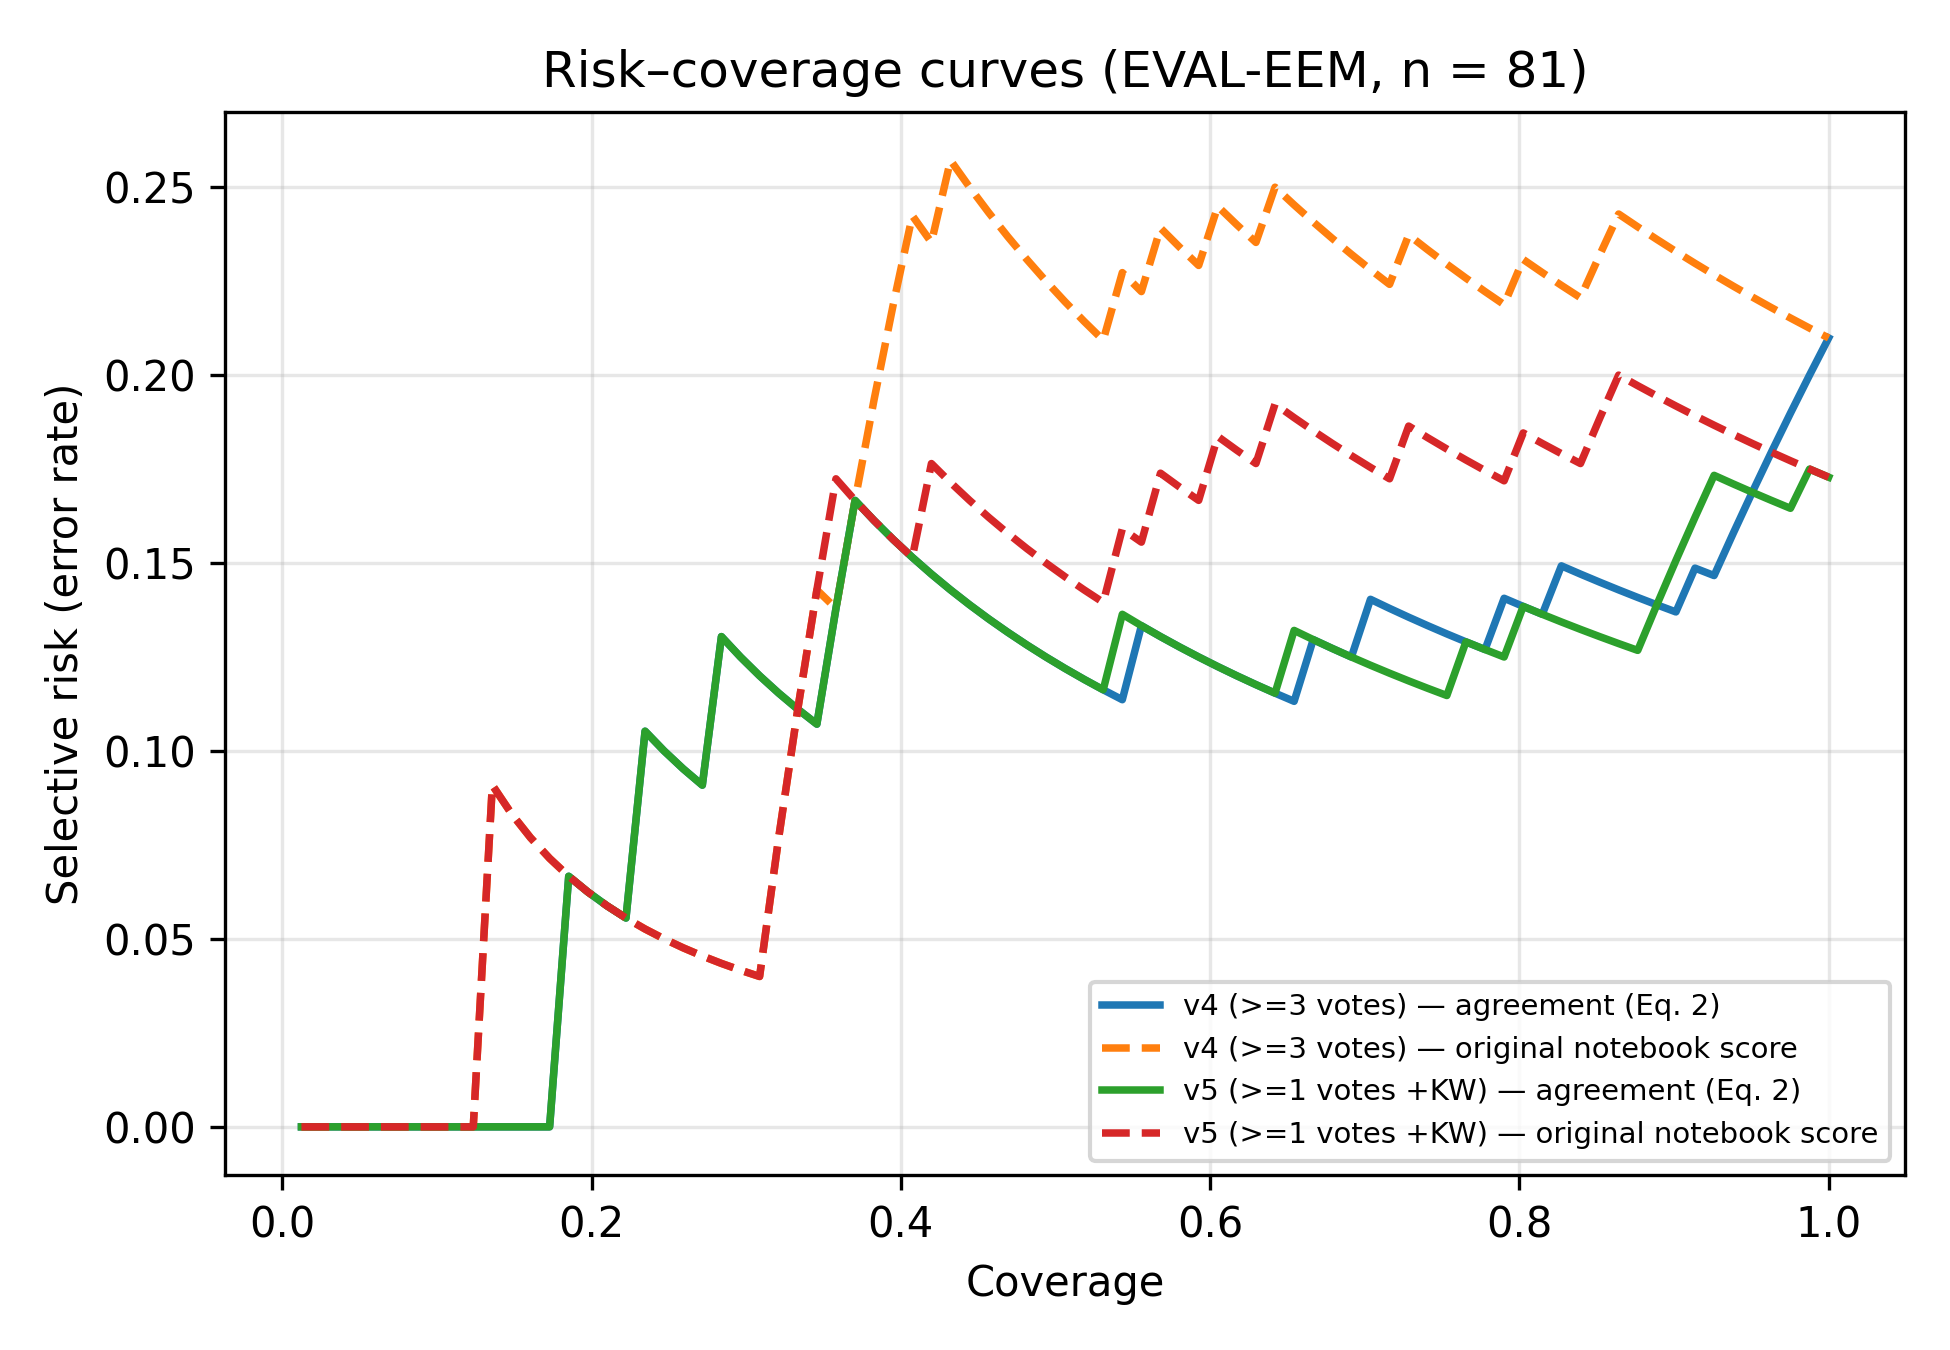

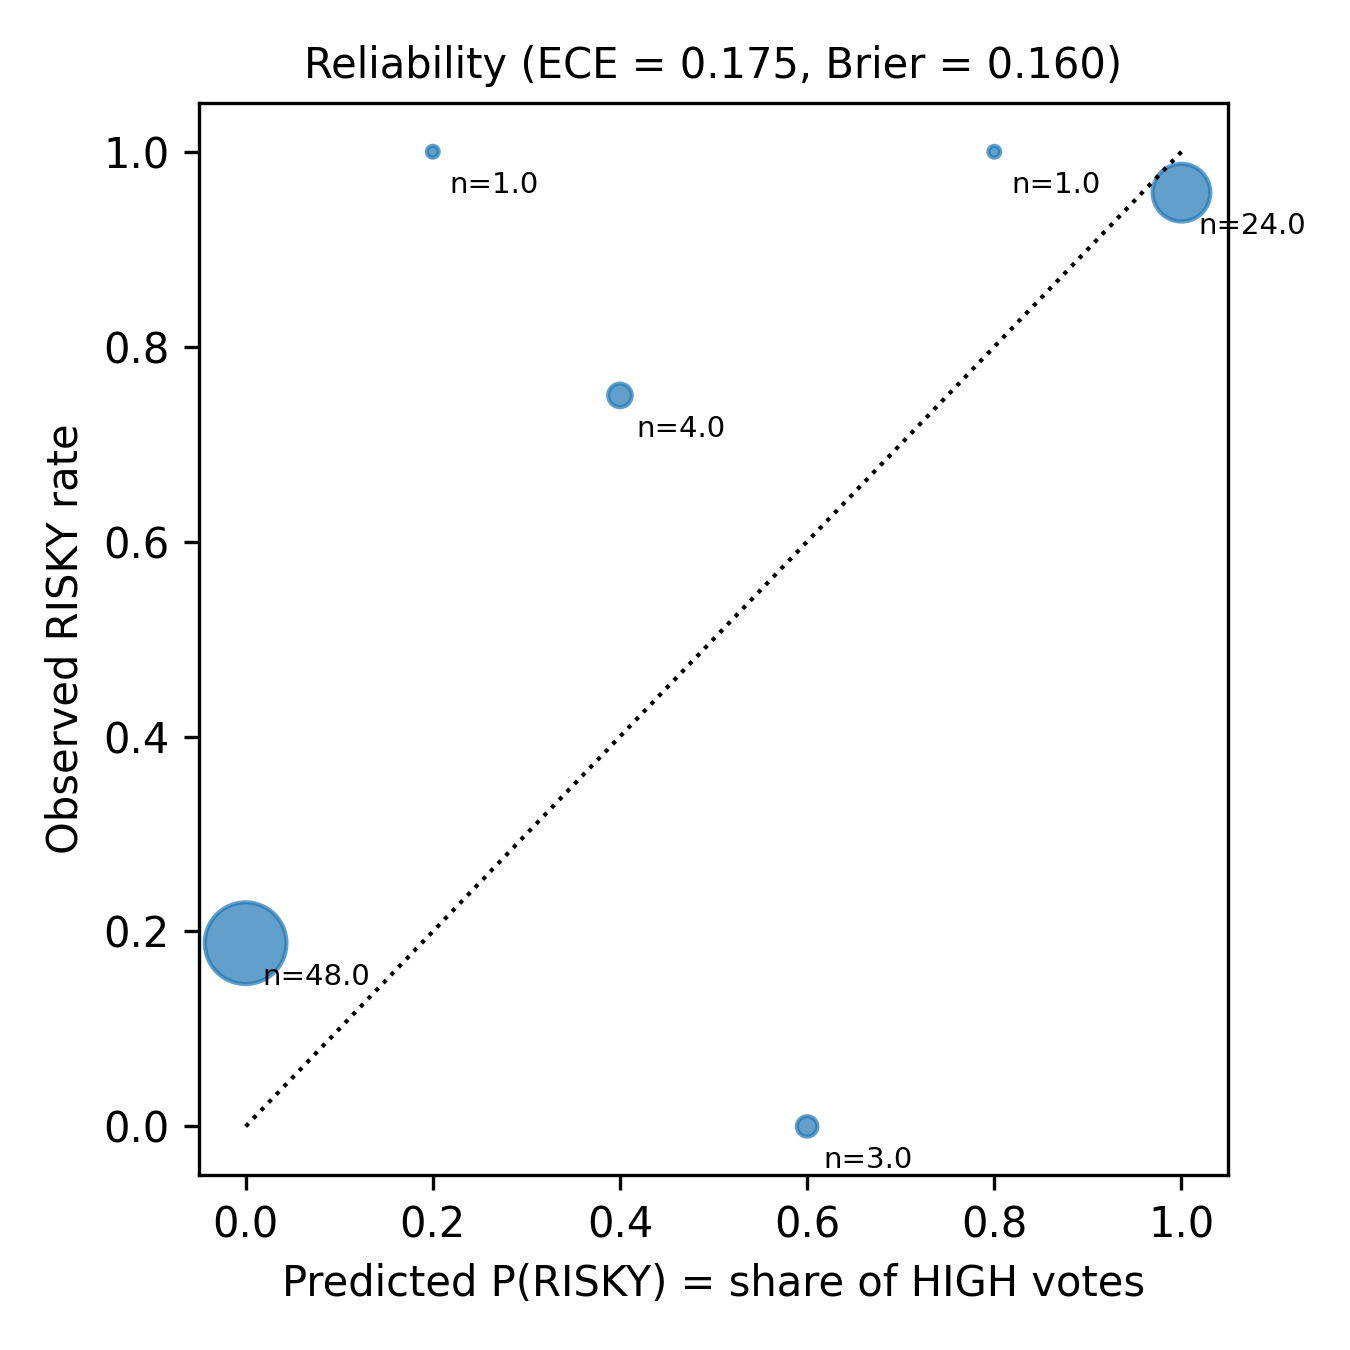

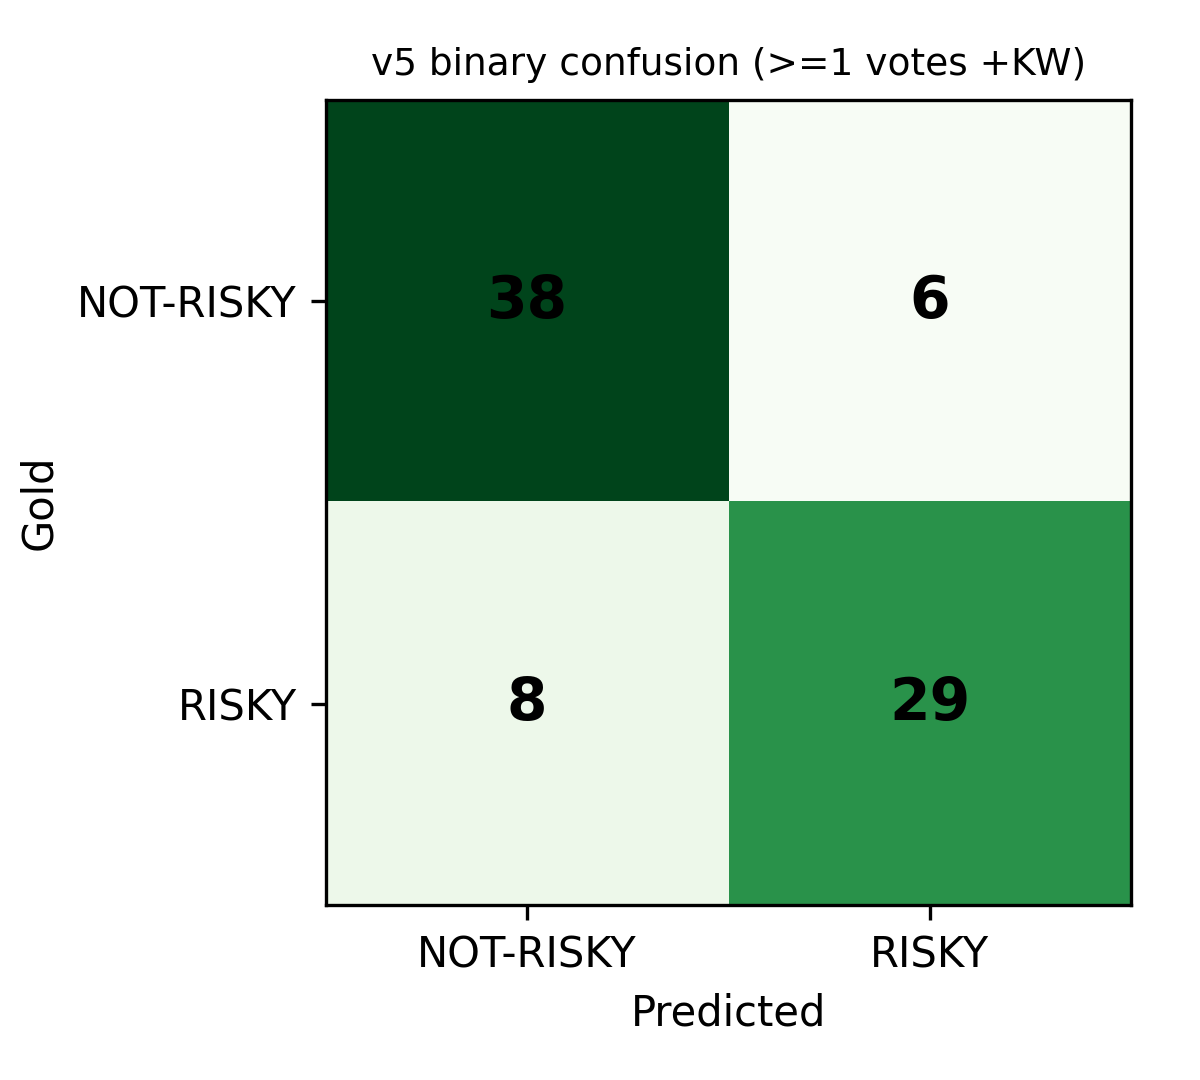

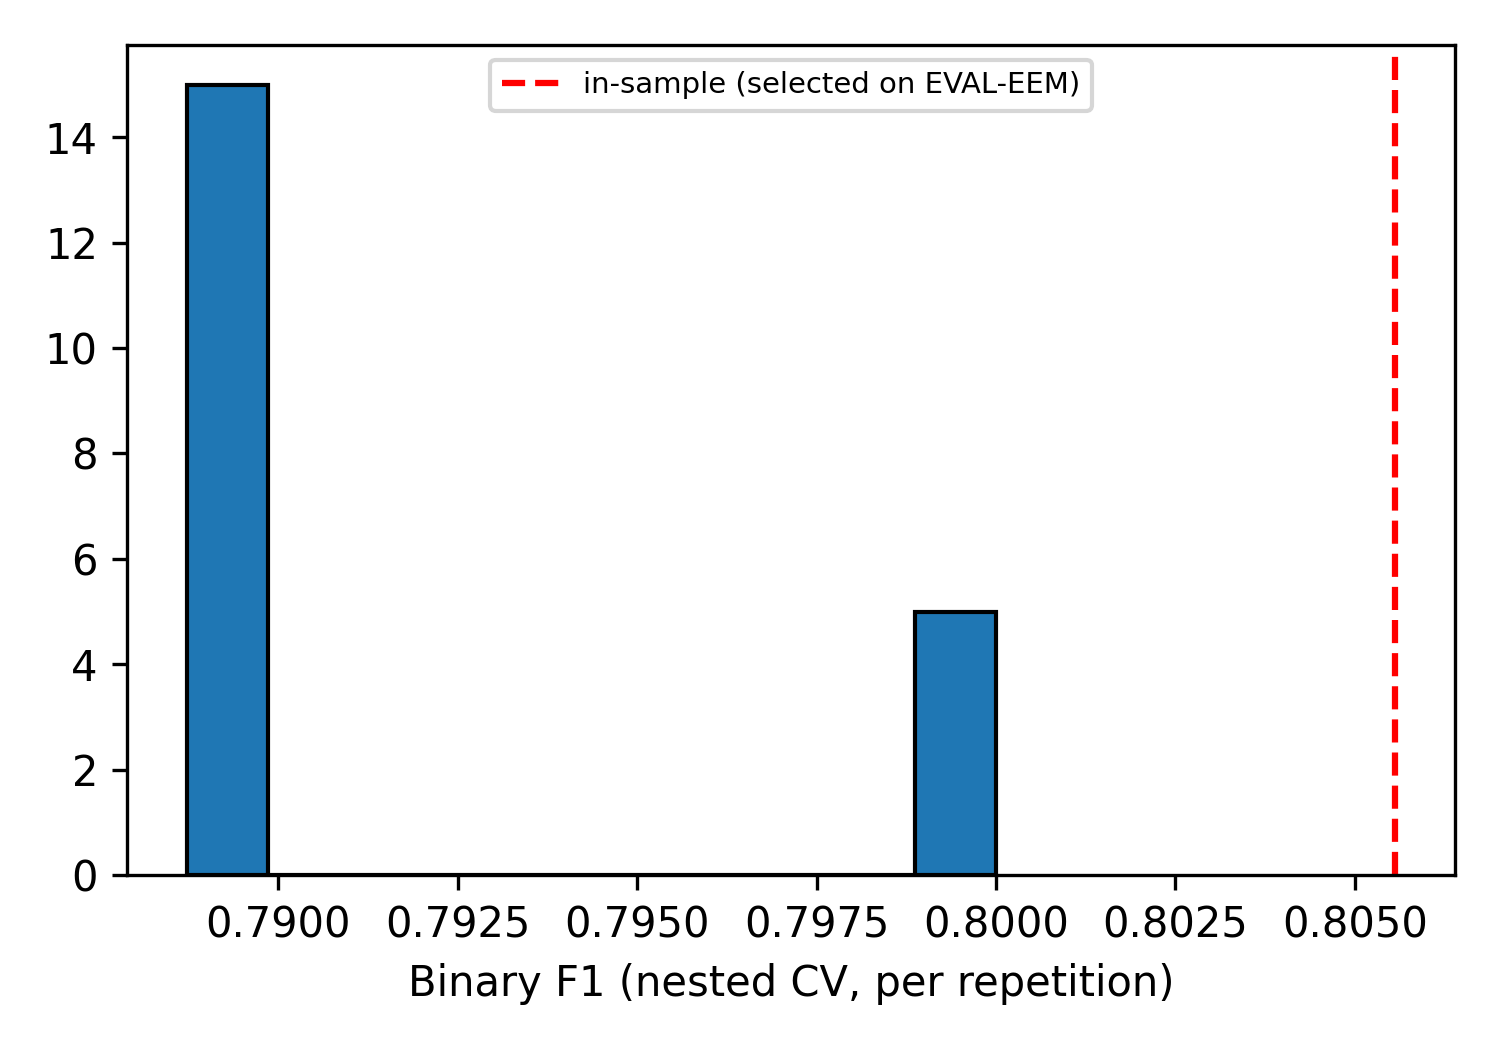

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from IPython.display import Image, display
import shutil
for f in ['risk_coverage','reliability','confusion_v5_binary','nested_cv_f1']:
    display(Image(f'{OUT_DIR}/{f}.png', width=500))
shutil.make_archive('revision_outputs', 'zip', OUT_DIR)
files.download('revision_outputs.zip')